#  Clustering
## Python practical for Google Colab

This notebook provides an intrpduction to **Clustering**. It follows the following sequence:

1. introduce clustering;
2. explore `mtcars`;
3. calculate distances;
4. perform hierarchical clustering and draw dendrograms;
5. explore the Iris data;
6. perform hierarchical clustering on an Iris sample;
7. fit a three-cluster k-means solution;
8. compare discovered clusters with known Iris species;
9. repeat the process for `mtcars`.

The notebook uses `pandas`, `matplotlib`, `seaborn`, `scipy` and `scikit-learn`, all of which are available in a standard Google Colab runtime.

### Learning outcomes
By the end of the practical, you should be able to:

- explain the purpose of clustering;
- calculate and interpret Euclidean distance;
- explain why feature scaling matters;
- perform hierarchical clustering;
- interpret a dendrogram;
- perform k-means clustering;
- choose and justify a value of $k$;
- compare discovered clusters with known labels where those labels are available;
- describe limitations of hierarchical and k-means clustering.

> Run the cells in order. Exercises include blank work cells followed by expandable worked solutions.


## 1. Preliminaries

Load the libraries used throughout the practical.


In [1]:
import io
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import euclidean, pdist, squareform
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
rng = np.random.default_rng(42)


## 2. What is clustering?

Clustering is an **unsupervised learning** technique that creates groups within data. The goal is for observations within a cluster to be more similar to one another than to observations in other clusters.

This practical examines two methods:

- **Hierarchical clustering**, which successively joins observations and groups into a hierarchy;
- **K-means clustering**, which partitions observations into a chosen number, $k$, of clusters.

The clustering algorithm does not use the known Iris species labels when discovering groups. We retain the labels only to interpret the data and evaluate the clustering afterwards.


# Part A — The `mtcars` example
## 3. Load the `mtcars` dataset

The `mtcars` dataset contains fuel consumption and automobile design and performance characteristics for 32 cars from the 1973–74 *Motor Trend* US magazine.

The data are embedded so that the notebook is self-contained.


In [ ]:
mtcars_csv = """model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4
Merc 280C,17.8,6,167.6,123,3.92,3.440,18.90,1,0,4,4
Merc 450SE,16.4,8,275.8,180,3.07,4.070,17.40,0,0,3,3
Merc 450SL,17.3,8,275.8,180,3.07,3.730,17.60,0,0,3,3
Merc 450SLC,15.2,8,275.8,180,3.07,3.780,18.00,0,0,3,3
Cadillac Fleetwood,10.4,8,472.0,205,2.93,5.250,17.98,0,0,3,4
Lincoln Continental,10.4,8,460.0,215,3.00,5.424,17.82,0,0,3,4
Chrysler Imperial,14.7,8,440.0,230,3.23,5.345,17.42,0,0,3,4
Fiat 128,32.4,4,78.7,66,4.08,2.200,19.47,1,1,4,1
Honda Civic,30.4,4,75.7,52,4.93,1.615,18.52,1,1,4,2
Toyota Corolla,33.9,4,71.1,65,4.22,1.835,19.90,1,1,4,1
Toyota Corona,21.5,4,120.1,97,3.70,2.465,20.01,1,0,3,1
Dodge Challenger,15.5,8,318.0,150,2.76,3.520,16.87,0,0,3,2
AMC Javelin,15.2,8,304.0,150,3.15,3.435,17.30,0,0,3,2
Camaro Z28,13.3,8,350.0,245,3.73,3.840,15.41,0,0,3,4
Pontiac Firebird,19.2,8,400.0,175,3.08,3.845,17.05,0,0,3,2
Fiat X1-9,27.3,4,79.0,66,4.08,1.935,18.90,1,1,4,1
Porsche 914-2,26.0,4,120.3,91,4.43,2.140,16.70,0,1,5,2
Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.90,1,1,5,2
Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.50,0,1,5,4
Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.50,0,1,5,6
Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.60,0,1,5,8
Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.60,1,1,4,2
"""
mtcars = pd.read_csv(io.StringIO(mtcars_csv)).set_index("model")
mtcars.head()



,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
data = pd.read_csv("Data/mtcars.csv")
mtcars.head()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
model,,,,,,,,,,,
Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [ ]:
print(f"Rows: {mtcars.shape[0]}")
print(f"Variables: {mtcars.shape[1]}")
display(mtcars.describe().T)
print("Missing values:", int(mtcars.isna().sum().sum()))


Rows: 32
Variables: 11


,count,mean,std,min,25%,50%,75%,max
mpg,32.0,20.090625,6.026948,10.400,15.42500,19.200,22.80,33.900
cyl,32.0,6.187500,1.785922,4.000,4.00000,6.000,8.00,8.000
disp,32.0,230.721875,123.938694,71.100,120.82500,196.300,326.00,472.000
hp,32.0,146.687500,68.562868,52.000,96.50000,123.000,180.00,335.000
drat,32.0,3.596563,0.534679,2.760,3.08000,3.695,3.92,4.930
wt,32.0,3.217250,0.978457,1.513,2.58125,3.325,3.61,5.424
qsec,32.0,17.848750,1.786943,14.500,16.89250,17.710,18.90,22.900
vs,32.0,0.437500,0.504016,0.000,0.00000,0.000,1.00,1.000
am,32.0,0.406250,0.498991,0.000,0.00000,0.000,1.00,1.000
gear,32.0,3.687500,0.737804,3.000,3.00000,4.000,4.00,5.000


Missing values: 0


## 4. Explore pairwise relationships

The original practical uses the first four variables: `mpg`, `cyl`, `disp` and `hp`. A scatterplot matrix can reveal associations, groups and unusual observations before clustering.


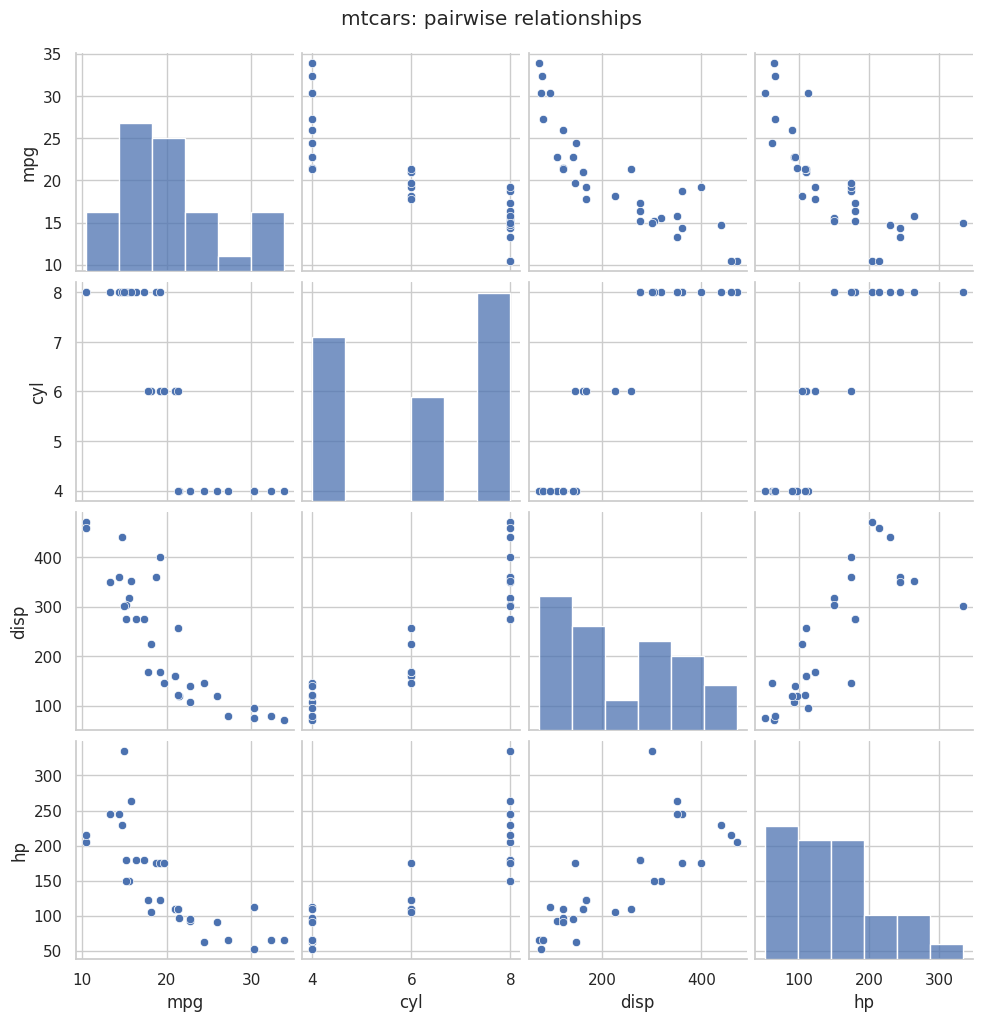

In [ ]:
mtcars_features_4 = ["mpg", "cyl", "disp", "hp"]
sns.pairplot(mtcars[mtcars_features_4], corner=False, diag_kind="hist")
plt.suptitle("mtcars: pairwise relationships", y=1.02)
plt.show()


## 5. Euclidean distance

For observations $x$ and $y$ with $p$ features, Euclidean distance is

$$d(x,y)=\sqrt{\sum_{j=1}^{p}(x_j-y_j)^2}.$$

A smaller distance means that the observations are more similar according to the included features and their scales.


In [ ]:
honda = mtcars.loc["Honda Civic"]
camaro = mtcars.loc["Camaro Z28"]
firebird = mtcars.loc["Pontiac Firebird"]

honda_camaro_distance = euclidean(honda, camaro)
camaro_firebird_distance = euclidean(camaro, firebird)

print(f"Honda Civic ↔ Camaro Z28: {honda_camaro_distance:.4f}")
print(f"Camaro Z28 ↔ Pontiac Firebird: {camaro_firebird_distance:.4f}")


Honda Civic ↔ Camaro Z28: 335.8883
Camaro Z28 ↔ Pontiac Firebird: 86.2666


The Camaro Z28–Pontiac Firebird distance is smaller than the Honda Civic–Camaro Z28 distance. Under this definition of distance, the Camaro is therefore more similar to the Pontiac than to the Honda.


### Exercise 1 — Calculate distances

Calculate the full-variable Euclidean distances from the Mazda RX4 to the Mazda RX4 Wag and to the Maserati Bora. Which pair is more similar?


In [ ]:
# Write your answer here



<details><summary><strong>Worked solution</strong></summary>

```python
mazda = mtcars.loc['Mazda RX4']
mazda_wag = mtcars.loc['Mazda RX4 Wag']
maserati = mtcars.loc['Maserati Bora']
print('Mazda RX4 ↔ Mazda RX4 Wag:', euclidean(mazda, mazda_wag))
print('Mazda RX4 ↔ Maserati Bora:', euclidean(mazda, maserati))
# The smaller distance identifies the more similar pair under these features and scales.
```
</details>


## 6. Full distance matrix

`pdist` computes pairwise distances. `squareform` converts the condensed result into a symmetrical matrix.


In [ ]:
mtcars_distance_matrix = pd.DataFrame(
    squareform(pdist(mtcars.values, metric="euclidean")),
    index=mtcars.index,
    columns=mtcars.index
)
mtcars_distance_matrix.iloc[:8, :8].round(1)


model,Mazda RX4,Mazda RX4 Wag,Datsun 710,Hornet 4 Drive,Hornet Sportabout,Valiant,Duster 360,Merc 240D
model,,,,,,,,
Mazda RX4,0.0,0.6,54.9,98.1,210.3,65.5,241.4,50.2
Mazda RX4 Wag,0.6,0.0,54.9,98.1,210.3,65.4,241.4,50.1
Datsun 710,54.9,54.9,0.0,151.0,265.1,117.8,294.5,49.7
Hornet 4 Drive,98.1,98.1,151.0,0.0,121.0,33.6,169.4,121.3
Hornet Sportabout,210.3,210.3,265.1,121.0,0.0,152.1,70.2,241.5
Valiant,65.5,65.4,117.8,33.6,152.1,0.0,194.6,89.6
Duster 360,241.4,241.4,294.5,169.4,70.2,194.6,0.0,281.3
Merc 240D,50.2,50.1,49.7,121.3,241.5,89.6,281.3,0.0


## 7. Why scaling matters

The variables use very different units. `disp` takes values in the hundreds, whereas `wt` is measured in thousands of pounds and often lies between roughly 1.5 and 5.5. Without scaling, variables with larger numerical spread can dominate Euclidean distance.

Standardisation transforms each feature to mean 0 and standard deviation 1:

$$z_{ij}=\frac{x_{ij}-\bar{x}_j}{s_j}.$$




In [ ]:
mtcars_scale_summary = pd.DataFrame({
    "mean": mtcars.mean(),
    "standard_deviation": mtcars.std(),
    "range": mtcars.max() - mtcars.min()
}).sort_values("range", ascending=False)
mtcars_scale_summary.round(2)


,mean,standard_deviation,range
disp,230.72,123.94,400.90
hp,146.69,68.56,283.00
mpg,20.09,6.03,23.50
qsec,17.85,1.79,8.40
carb,2.81,1.62,7.00
cyl,6.19,1.79,4.00
wt,3.22,0.98,3.91
drat,3.60,0.53,2.17
gear,3.69,0.74,2.00
am,0.41,0.50,1.00


In [ ]:
scaler_mtcars = StandardScaler()
mtcars_scaled = pd.DataFrame(
    scaler_mtcars.fit_transform(mtcars),
    index=mtcars.index,
    columns=mtcars.columns
)
mtcars_scaled.describe().loc[["mean", "std"]].round(2)


,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00
std,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02,1.02


In [ ]:
print("Unscaled distances")
print("Honda ↔ Camaro:", round(euclidean(honda, camaro), 3))
print("Camaro ↔ Firebird:", round(euclidean(camaro, firebird), 3))
print()
print("Scaled distances")
print("Honda ↔ Camaro:", round(euclidean(mtcars_scaled.loc['Honda Civic'], mtcars_scaled.loc['Camaro Z28']), 3))
print("Camaro ↔ Firebird:", round(euclidean(mtcars_scaled.loc['Camaro Z28'], mtcars_scaled.loc['Pontiac Firebird']), 3))


Unscaled distances
Honda ↔ Camaro: 335.888
Camaro ↔ Firebird: 86.267

Scaled distances
Honda ↔ Camaro: 7.216
Camaro ↔ Firebird: 2.492


Scaling changes the geometry of the data and therefore can change the clustering. It is an analytical decision, not merely a cosmetic one.


# Part B — Hierarchical clustering
## 8. How hierarchical clustering works

Agglomerative hierarchical clustering begins with each observation in its own cluster. It repeatedly joins the closest observations or clusters until all observations belong to one hierarchy.

The result depends on:

- the selected features;
- the feature scaling;
- the distance metric;
- the **linkage** rule used to measure distance between clusters.

The original practical uses complete linkage, so we use `method="complete"` below.


## 9. Hierarchical clustering of `mtcars`


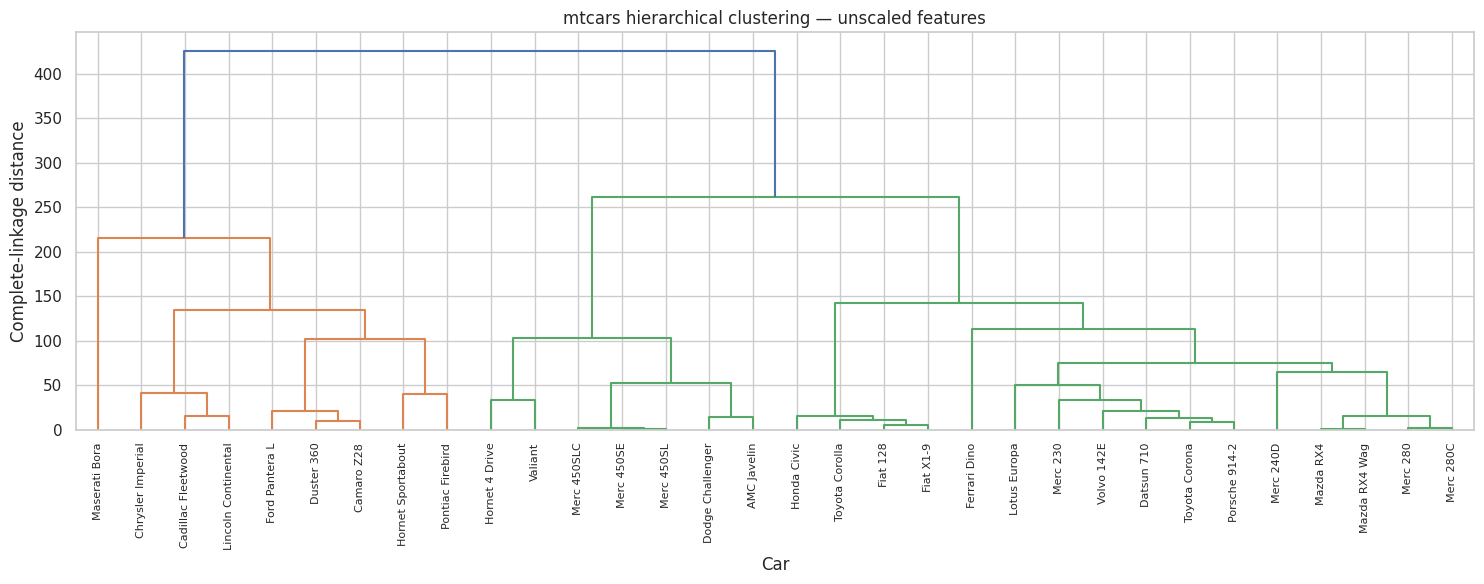

In [ ]:
mtcars_linkage_unscaled = linkage(mtcars.values, method="complete", metric="euclidean")

plt.figure(figsize=(15, 6))
dendrogram(mtcars_linkage_unscaled, labels=mtcars.index, leaf_rotation=90, leaf_font_size=8)
plt.title("mtcars hierarchical clustering — unscaled features")
plt.xlabel("Car")
plt.ylabel("Complete-linkage distance")
plt.tight_layout()
plt.show()


The dendrogram shows which observations join at low or high distances. A horizontal cut through the tree defines a cluster solution. The plot does not force one uniquely correct number of clusters.


## 10. Compare with a scaled dendrogram


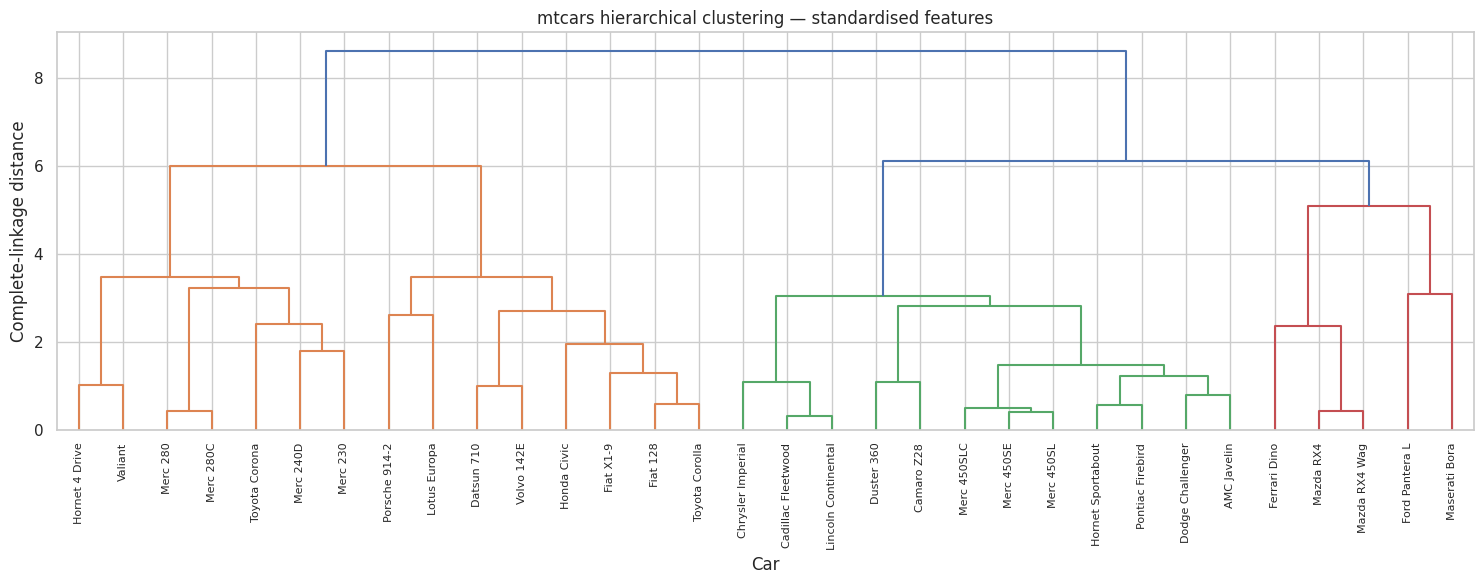

In [ ]:
mtcars_linkage_scaled = linkage(mtcars_scaled.values, method="complete", metric="euclidean")

plt.figure(figsize=(15, 6))
dendrogram(mtcars_linkage_scaled, labels=mtcars.index, leaf_rotation=90, leaf_font_size=8)
plt.title("mtcars hierarchical clustering — standardised features")
plt.xlabel("Car")
plt.ylabel("Complete-linkage distance")
plt.tight_layout()
plt.show()


## 11. Cut the scaled hierarchy into clusters

The following cell creates a three-cluster solution for inspection. The choice of three is illustrative rather than automatically correct.


In [ ]:
mtcars_hierarchical_3 = fcluster(mtcars_linkage_scaled, t=3, criterion="maxclust")
mtcars_hierarchical_results = mtcars.assign(hierarchical_cluster=mtcars_hierarchical_3)
mtcars_hierarchical_results[["mpg", "cyl", "disp", "hp", "wt", "hierarchical_cluster"]].sort_values("hierarchical_cluster")


,mpg,cyl,disp,hp,wt,hierarchical_cluster
model,,,,,,
Hornet 4 Drive,21.4,6,258.0,110,3.215,1
Datsun 710,22.8,4,108.0,93,2.320,1
Merc 240D,24.4,4,146.7,62,3.190,1
Valiant,18.1,6,225.0,105,3.460,1
Merc 280,19.2,6,167.6,123,3.440,1
Merc 280C,17.8,6,167.6,123,3.440,1
Merc 230,22.8,4,140.8,95,3.150,1
Fiat 128,32.4,4,78.7,66,2.200,1
Fiat X1-9,27.3,4,79.0,66,1.935,1


In [ ]:
mtcars_hierarchical_results.groupby("hierarchical_cluster").agg(
    cars=("hierarchical_cluster", "size"),
    mean_mpg=("mpg", "mean"),
    mean_cylinders=("cyl", "mean"),
    mean_displacement=("disp", "mean"),
    mean_horsepower=("hp", "mean"),
    mean_weight=("wt", "mean")
).round(2)


,cars,mean_mpg,mean_cylinders,mean_displacement,mean_horsepower,mean_weight
hierarchical_cluster,,,,,,
1,15,24.65,4.53,131.65,91.33,2.58
2,12,15.05,8.00,357.62,194.17,4.10
3,5,18.50,6.80,223.40,198.80,3.00


### Exercise 2 — Interpret the hierarchy

Inspect the scaled dendrogram and compare two-, three- and four-cluster cuts. Describe which cars move together and choose one solution for interpretation.


In [ ]:
for k in [2,3,4]:
    labels = fcluster(mtcars_linkage_scaled, t=k, criterion='maxclust')
    print(f'\n{k} clusters')
    display(pd.Series(labels, index=mtcars.index, name='cluster').sort_values().to_frame())


2 clusters


,cluster
model,
Hornet 4 Drive,1
Datsun 710,1
Merc 240D,1
Valiant,1
Merc 280,1
Merc 280C,1
Merc 230,1
Fiat 128,1
Fiat X1-9,1



3 clusters


,cluster
model,
Hornet 4 Drive,1
Datsun 710,1
Merc 240D,1
Valiant,1
Merc 280,1
Merc 280C,1
Merc 230,1
Fiat 128,1
Fiat X1-9,1



4 clusters


,cluster
model,
Hornet 4 Drive,1
Valiant,1
Merc 240D,1
Merc 230,1
Merc 280,1
Merc 280C,1
Toyota Corona,1
Datsun 710,2
Fiat X1-9,2


<details><summary><strong>Worked solution</strong></summary>

```python
for k in [2,3,4]:
    labels = fcluster(mtcars_linkage_scaled, t=k, criterion='maxclust')
    print(f'
{k} clusters')
    display(pd.Series(labels, index=mtcars.index, name='cluster').sort_values().to_frame())
```
</details>


# Part C — The Iris dataset
## 12. Load and inspect Iris

The Iris dataset contains 150 observations from three known species: setosa, versicolor and virginica. Each observation has four measurements:

- sepal length;
- sepal width;
- petal length;
- petal width.

Clustering uses the four numeric features, not the species label.


In [ ]:
iris_bunch = load_iris(as_frame=True)
iris = iris_bunch.frame.rename(columns={
    "sepal length (cm)":"sepal_length",
    "sepal width (cm)":"sepal_width",
    "petal length (cm)":"petal_length",
    "petal width (cm)":"petal_width"
})
iris["species"] = iris["target"].map(dict(enumerate(iris_bunch.target_names)))
iris = iris.drop(columns="target")
iris.head()


In [ ]:
print(iris.shape)
display(iris.describe(include="all").T)
display(iris["species"].value_counts().to_frame("count"))


## 13. Petal length and width without species labels

This is the view available to an unsupervised clustering algorithm.


In [ ]:
plt.scatter(iris["petal_length"], iris["petal_width"], alpha=0.75)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris data without species labels")
plt.show()


## 14. Reveal the known species for interpretation

The labels are used here to understand the data, not to fit the clustering algorithm.


In [ ]:
sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species", style="species", s=70)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris petal measurements by known species")
plt.show()


Setosa separates clearly in petal space. Versicolor and virginica overlap more, so a clustering method may not recover those two species perfectly.


## 15. Scatterplot matrix


In [ ]:
iris_features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
sns.pairplot(iris, vars=iris_features, hue="species", corner=False)
plt.suptitle("Iris feature relationships by known species", y=1.02)
plt.show()


## 16. Scale the Iris features

All four variables are measured in centimetres, but they have different spreads. Standardisation gives each feature equal variance before distance-based clustering.


In [ ]:
X_iris = iris[iris_features]
iris_scaler = StandardScaler()
X_iris_scaled = pd.DataFrame(
    iris_scaler.fit_transform(X_iris),
    columns=iris_features,
    index=iris.index
)
X_iris_scaled.describe().loc[["mean", "std"]].round(2)


# Part D — Hierarchical clustering of Iris
## 17. Sample 40 observations

The original practical samples 40 observations to keep the dendrogram readable. We use a fixed seed to make the sample reproducible.


In [ ]:
sample_indices = rng.choice(iris.index, size=40, replace=False)
iris_sample = iris.loc[sample_indices].copy()
iris_sample_scaled = X_iris_scaled.loc[sample_indices]
iris_sample["label"] = iris_sample["species"] + "_" + iris_sample.index.astype(str)
iris_sample.head()


## 18. Draw the Iris dendrogram


In [ ]:
iris_sample_linkage = linkage(iris_sample_scaled.values, method="complete", metric="euclidean")

plt.figure(figsize=(15, 6))
dendrogram(
    iris_sample_linkage,
    labels=iris_sample["label"].to_list(),
    leaf_rotation=90,
    leaf_font_size=8
)
plt.title("Iris sample: complete-linkage hierarchical clustering")
plt.xlabel("Known species and row index — labels used only for interpretation")
plt.ylabel("Complete-linkage distance")
plt.tight_layout()
plt.show()


## 19. Compare a three-cluster cut with species


In [ ]:
iris_hierarchical_3 = fcluster(iris_sample_linkage, t=3, criterion="maxclust")
hierarchical_comparison = pd.crosstab(
    iris_sample["species"],
    iris_hierarchical_3,
    rownames=["Known species"],
    colnames=["Hierarchical cluster"]
)
hierarchical_comparison


In [ ]:
hierarchical_ari = adjusted_rand_score(iris_sample["species"], iris_hierarchical_3)
print(f"Adjusted Rand Index: {hierarchical_ari:.3f}")


The Adjusted Rand Index compares two partitions without requiring cluster numbers to correspond to species names. A value of 1 indicates identical partitions; values near 0 indicate agreement close to chance.


### Exercise 3 — Repeat the sample

Change the random seed, draw a new 40-observation dendrogram and compare a three-cluster cut with species. Does the result change?


In [ ]:
# Write your answer here


<details><summary><strong>Worked solution</strong></summary>

```python
local_rng = np.random.default_rng(10)
idx = local_rng.choice(iris.index, size=40, replace=False)
Z = linkage(X_iris_scaled.loc[idx], method='complete')
labels = fcluster(Z, t=3, criterion='maxclust')
plt.figure(figsize=(15,6))
dendrogram(Z, labels=iris.loc[idx, 'species'].to_list(), leaf_rotation=90)
plt.show()
display(pd.crosstab(iris.loc[idx, 'species'], labels))
print('ARI:', adjusted_rand_score(iris.loc[idx, 'species'], labels))
```
</details>


# Part E — K-means clustering
## 20. How k-means works

K-means partitions observations into $k$ clusters by iterating between two operations:

1. assign each observation to its nearest cluster centre;
2. update each centre to the mean of its assigned observations.

The algorithm seeks to minimise the total within-cluster sum of squared distances.

Unlike hierarchical clustering, k-means requires $k$ to be specified before fitting. Results can depend on initial centres, so we use several initialisations through `n_init` and set a random seed.


## 21. Fit k-means to Iris with k = 3

We choose three here because the original practical knows that the dataset contains three species. In a genuinely unlabelled application, $k$ would need to be justified using structure, domain knowledge and validation measures.


In [ ]:
kmeans_iris = KMeans(n_clusters=3, n_init=30, random_state=42)
iris_cluster = kmeans_iris.fit_predict(X_iris_scaled)

print("Cluster sizes:")
print(pd.Series(iris_cluster).value_counts().sort_index())
print()
print("Total within-cluster sum of squares:", round(kmeans_iris.inertia_, 3))


## 22. Cluster centres

The centres below are returned on the standardised scale. We also transform them back to the original centimetre scale for interpretation.


In [ ]:
centres_standardised = pd.DataFrame(kmeans_iris.cluster_centers_, columns=iris_features)
centres_original = pd.DataFrame(
    iris_scaler.inverse_transform(kmeans_iris.cluster_centers_),
    columns=iris_features
)
print("Standardised centres")
display(centres_standardised.round(2))
print("Centres in original units")
display(centres_original.round(2))


## 23. Compare clusters with known species

Cluster numbers are arbitrary labels. Cluster 0 is not inherently the first species, and a different run may permute the cluster numbers.


In [ ]:
iris_kmeans_comparison = pd.crosstab(
    iris["species"],
    iris_cluster,
    rownames=["Known species"],
    colnames=["K-means cluster"]
)
iris_kmeans_comparison


In [ ]:
print("Adjusted Rand Index:", round(adjusted_rand_score(iris["species"], iris_cluster), 3))
print("Silhouette score:", round(silhouette_score(X_iris_scaled, iris_cluster), 3))


## 24. Plot k-means clusters and centres

The model uses all four standardised measurements. The visualisation shows only sepal length and sepal width, so some separation in the full feature space may not be visible in this two-dimensional view.


In [ ]:
plt.figure(figsize=(8, 5.5))
plt.scatter(iris["sepal_length"], iris["sepal_width"], c=iris_cluster, cmap="viridis", alpha=0.75)
plt.scatter(
    centres_original["sepal_length"],
    centres_original["sepal_width"],
    c=[0,1,2], cmap="viridis", marker="D", s=220, edgecolor="black", label="Cluster centres"
)
plt.xlabel("Sepal length (cm)")
plt.ylabel("Sepal width (cm)")
plt.title("Iris k-means clusters shown in sepal space")
plt.legend()
plt.show()


## 25. Plot clusters in petal space


In [ ]:
plt.figure(figsize=(8, 5.5))
plt.scatter(iris["petal_length"], iris["petal_width"], c=iris_cluster, cmap="viridis", alpha=0.75)
plt.scatter(
    centres_original["petal_length"],
    centres_original["petal_width"],
    c=[0,1,2], cmap="viridis", marker="D", s=220, edgecolor="black"
)
plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris k-means clusters shown in petal space")
plt.show()


Setosa is usually recovered well. Versicolor and virginica overlap, so some observations are assigned to clusters dominated by the other species. Clustering and biological species are related but not identical concepts.


# Part F — Choosing k
## 26. Elbow plot

The within-cluster sum of squares always decreases as $k$ increases. The elbow method looks for a point after which additional clusters provide diminishing improvement.


In [ ]:
inertias = []
silhouettes = []
k_values = range(2, 9)

for k in k_values:
    model = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = model.fit_predict(X_iris_scaled)
    inertias.append(model.inertia_)
    silhouettes.append(silhouette_score(X_iris_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_values), inertias, marker="o")
axes[0].set(xlabel="Number of clusters, k", ylabel="Within-cluster sum of squares", title="Elbow plot")
axes[1].plot(list(k_values), silhouettes, marker="o")
axes[1].set(xlabel="Number of clusters, k", ylabel="Silhouette score", title="Silhouette analysis")
plt.tight_layout()
plt.show()


The silhouette score measures whether observations are, on average, closer to their own cluster than to neighbouring clusters. Larger values indicate more separated clusters. Neither the elbow nor silhouette score replaces subject knowledge or interpretability.


### Exercise 4 — Choose k for Iris

Fit k-means for k = 2, 3, 4 and 5. Compare inertia, silhouette score and the biological interpretability of the cluster centres. State which k you would retain and why.


In [ ]:
# Write your answer here


<details><summary><strong>Worked solution</strong></summary>

```python
rows=[]
for k in [2,3,4,5]:
    model=KMeans(n_clusters=k,n_init=30,random_state=42)
    labels=model.fit_predict(X_iris_scaled)
    rows.append({'k':k,'inertia':model.inertia_,'silhouette':silhouette_score(X_iris_scaled,labels)})
pd.DataFrame(rows)
# The choice should consider separation, the shape of the data and the purpose of the analysis—not only one score.
```
</details>


# Part G — Activity: repeat k-means for `mtcars`
## 27. Investigate a reasonable number of clusters

The original practical asks how many clusters to choose for `mtcars` and why. We begin by comparing elbow and silhouette measures on the standardised features.


In [ ]:
mtcars_inertias = []
mtcars_silhouettes = []
mtcars_k_values = range(2, 9)

for k in mtcars_k_values:
    model = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = model.fit_predict(mtcars_scaled)
    mtcars_inertias.append(model.inertia_)
    mtcars_silhouettes.append(silhouette_score(mtcars_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(mtcars_k_values), mtcars_inertias, marker="o")
axes[0].set(xlabel="Number of clusters, k", ylabel="Within-cluster sum of squares", title="mtcars elbow plot")
axes[1].plot(list(mtcars_k_values), mtcars_silhouettes, marker="o")
axes[1].set(xlabel="Number of clusters, k", ylabel="Silhouette score", title="mtcars silhouette analysis")
plt.tight_layout()
plt.show()


## 28. Fit an illustrative three-cluster `mtcars` solution

Three clusters are used here to inspect one plausible solution. You should compare this with alternatives rather than treating three as automatically correct.


In [ ]:
mtcars_kmeans = KMeans(n_clusters=3, n_init=50, random_state=42)
mtcars_kmeans_cluster = mtcars_kmeans.fit_predict(mtcars_scaled)
mtcars_clustered = mtcars.assign(kmeans_cluster=mtcars_kmeans_cluster)

print("Cluster sizes")
display(mtcars_clustered["kmeans_cluster"].value_counts().sort_index().to_frame("cars"))
print("Cluster profiles")
display(mtcars_clustered.groupby("kmeans_cluster").mean().round(2))


In [ ]:
for cluster in sorted(mtcars_clustered["kmeans_cluster"].unique()):
    print()
    print(f"Cluster {cluster}")
    print(", ".join(mtcars_clustered.index[mtcars_clustered["kmeans_cluster"] == cluster]))


## 29. Visualise `mtcars` clusters

The model uses all standardised features. This two-dimensional plot shows weight and fuel consumption only.


In [ ]:
plt.figure(figsize=(8, 5.5))
plt.scatter(mtcars["wt"], mtcars["mpg"], c=mtcars_kmeans_cluster, cmap="viridis", s=80)
for car, row in mtcars.iterrows():
    plt.annotate(car, (row["wt"], row["mpg"]), fontsize=7, alpha=0.75, xytext=(3,3), textcoords="offset points")
plt.xlabel("Weight (1,000 lb)")
plt.ylabel("Miles per gallon")
plt.title("mtcars k-means clusters")
plt.show()


## 30. Compare hierarchical and k-means partitions

Because cluster labels are arbitrary, the crosstab shows overlap between partitions rather than a direct cluster-number match. The Adjusted Rand Index provides a label-invariant comparison.


In [ ]:
partition_comparison = pd.crosstab(
    mtcars_hierarchical_3,
    mtcars_kmeans_cluster,
    rownames=["Hierarchical cluster"],
    colnames=["K-means cluster"]
)
display(partition_comparison)
print("Adjusted Rand Index:", round(adjusted_rand_score(mtcars_hierarchical_3, mtcars_kmeans_cluster), 3))


### Exercise 5 — Choose clusters for mtcars

Use the plots, silhouette scores, cluster profiles and car memberships to choose k. Fit the selected model and describe each cluster in plain language.


In [ ]:
# Write your answer here


<details><summary><strong>Worked solution</strong></summary>

```python
chosen_k = 3  # replace with your justified choice
model = KMeans(n_clusters=chosen_k, n_init=50, random_state=42)
labels = model.fit_predict(mtcars_scaled)
result = mtcars.assign(cluster=labels)
display(result.groupby('cluster').mean().round(2))
for cluster in range(chosen_k):
    print(f'Cluster {cluster}:', ', '.join(result.index[result.cluster==cluster]))
```
</details>


# Part H — Limitations and good practice
## 31. What can go wrong?

### Hierarchical clustering

- can be computationally expensive as the number of observations grows;
- does not revise an earlier merge;
- changes when distance, scaling or linkage changes;
- dendrogram cuts can be subjective.

### K-means

- requires $k$ in advance;
- can converge to different local solutions;
- is sensitive to scale and outliers;
- works best for compact, roughly spherical clusters;
- uses means, so it is designed for numeric features.

### Both methods

- always return structure, even when the data do not contain meaningful natural groups;
- cluster labels do not automatically have scientific or operational meaning;
- a visually clear two-dimensional plot may not represent the full feature space;
- clustering should be checked for stability, interpretability and usefulness.


## 32. Responsible interpretation

Avoid saying that a cluster solution has "discovered the true groups" unless there is strong external evidence. A more defensible statement is:

> Under the selected features, scaling, distance and clustering method, the observations were partitioned into groups with these profiles.

Where known labels exist, as in Iris, they can help evaluate a clustering solution—but unsupervised clusters need not reproduce those labels exactly.


# Part I — Integrated exercise
## 33. Complete clustering investigation

Choose either Iris or `mtcars` and produce a short clustering report containing:

1. dataset description and observational unit;
2. selected features and justification;
3. missing-value check;
4. feature-scale summary;
5. standardisation decision;
6. pairwise visual exploration;
7. selected distance metric;
8. hierarchical dendrogram;
9. comparison of two possible dendrogram cuts;
10. elbow and silhouette plots;
11. selected k-means solution;
12. cluster sizes and profiles;
13. two-dimensional visualisation with a warning that the model used more features;
14. comparison with known labels, if available;
15. limitations and a cautious conclusion.


In [ ]:
# Build your integrated clustering analysis here


<details><summary><strong>Suggested analysis skeleton</strong></summary>

```python
features = [...]  # choose numeric features
X = data[features]

print(X.isna().sum())
display(X.describe().T)

X_scaled = StandardScaler().fit_transform(X)

Z = linkage(X_scaled, method="complete")
dendrogram(Z)
plt.show()

rows = []
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = model.fit_predict(X_scaled)
    rows.append({
        "k": k,
        "inertia": model.inertia_,
        "silhouette": silhouette_score(X_scaled, labels)
    })

display(pd.DataFrame(rows))
```

Your conclusion should state that the result is conditional on the analytical choices made.
</details>


## 34. Clustering checklist

### Data
- What is one observation?
- Are the features numeric and meaningful?
- Are values missing?
- Are features on different scales?

### Distance and method
- Which distance metric is used?
- Are features standardised?
- Which linkage rule is used?
- Why is k plausible?

### Evaluation
- Are cluster sizes sensible?
- Are cluster profiles interpretable?
- Is the solution stable across seeds or samples?
- Do elbow and silhouette measures support the choice?
- Do external labels offer a useful comparison?

### Communication
- Do not imply that cluster numbers have an inherent order.
- Do not treat a plotted two-dimensional view as the complete clustering space.
- State the choices and limitations clearly.


# Summary

- Clustering groups observations so that within-cluster similarity is greater than between-cluster similarity.
- Euclidean distance depends on the included features and their scales.
- Standardisation is usually important when features use different units.
- Hierarchical clustering produces a dendrogram; a cut defines a cluster solution.
- K-means requires the number of clusters in advance and minimises within-cluster squared distance.
- Elbow and silhouette analyses provide evidence but not an automatic answer.
- Iris setosa separates clearly, while versicolor and virginica overlap.
- Cluster labels are arbitrary and need interpretation through profiles and external knowledge.
- A good clustering analysis reports its assumptions, choices, stability and limitations.
